# Credit Card Fraud Detection
A complete college ML mini-project using the real ULB / Worldline transactions.
Six baseline and six tuned configurations compare Logistic Regression, Decision Tree,
and Random Forest with and without SMOTE. All learned transformations stay in training.

## 1. Problem Definition
Credit-card fraud causes financial loss and harms trust. Our objective is to identify
suspicious transactions for review from their numerical characteristics. The positive
class is fraud. A false negative misses fraud; a false positive flags a genuine customer
and creates investigation work. The goal is useful fraud detection with manageable alerts.

Fraud is extremely rare. A classifier predicting legitimate for every record achieves
about 99.83% accuracy on the original dataset but catches no fraud. We therefore use
**average precision (AP)** for tuning and model selection, and also report recall,
precision, F1, ROC-AUC, trapezoidal PR-AUC, accuracy, and confusion counts.

**Protocol:** exact deduplication → stratified 60/20/20 split → training-fold preprocessing,
selection and SMOTE → bounded CV tuning → validation model/threshold selection → frozen
test evaluation. A random split suits this classroom comparison; future-time evaluation
is needed for deployment. Every random seed is 42.

In [1]:
# Locate the repository whether Jupyter starts here or in notebooks/.
from pathlib import Path
import sys, json
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "src").is_dir(), "Open this notebook from the project or notebooks directory."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import joblib
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
from src.config import FEATURES, TrainingConfig
from src.data import load_dataset, audit_and_clean, split_dataset
from src.training import make_pipeline, run_training
from src.predict import load_artifacts, predict_transactions
from src.evaluation import compute_metrics
config = TrainingConfig()
RUN_TRAINING = False  # True repeats the complete experiment; expect several minutes.
pd.set_option("display.max_columns", 35)
pd.set_option("display.width", 160)
def table(path):
    # Preserve the string "None" used for no resampling.
    return pd.read_csv(ROOT / path, keep_default_na=False)
def figure(filename, insight):
    display(Image(filename=str(ROOT / "figures" / filename), width=1000))
    display(Markdown("**Insight:** " + insight))
print("Project directory:", ROOT.name, "| seed:", config.seed)

Project directory: ml-project | seed: 42


## 2. Dataset
Source: [Kaggle ULB / Worldline](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).
The automatic downloader uses the real CSV mirror linked in
[TensorFlow's official tutorial](https://www.tensorflow.org/tutorials/structured_data/imbalanced_data).
Original data: **284,807 transactions and 492 frauds**, observed over two days in
September 2013 from European cardholders. The data has 30 numeric predictors and one target.

| Attribute | Description |
|---|---|
| Time | Seconds since the first transaction |
| V1–V28 | Anonymized PCA components; business meanings and original transform unavailable |
| Amount | Transaction amount |
| Class | 0 legitimate, 1 fraud |

If the file is missing, run `python scripts/download_data.py`, or extract Kaggle's
`creditcard.csv` into `data/`. The loader validates column names, finite numeric data,
nonnegative Time/Amount, and binary labels. No fabricated data is substituted.

In [2]:
raw = load_dataset(ROOT / "data/creditcard.csv")
display(raw.head())
distribution = raw.Class.value_counts().sort_index().rename_axis("Class").to_frame("records")
distribution["percent"] = 100 * distribution.records / len(raw)
display(distribution)
print(f"Raw rows: {len(raw):,}; frauds: {raw.Class.sum():,}; features: {len(FEATURES)}")
provenance = ROOT / "data/creditcard.source.json"
if provenance.exists():
    display(Markdown("**Download provenance:** " + str(json.loads(provenance.read_text()))))

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


,records,percent
Class,,
0,284315,99.827251
1,492,0.172749


Raw rows: 284,807; frauds: 492; features: 30


**Download provenance:** {'source': 'https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud', 'mirror': 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv', 'sha256': '76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89', 'rows': 284807, 'frauds': 492}

## 3. Data Preprocessing
Inspect missing values and exact duplicates. The original CSV has no missing values;
a **training-fold median imputer** handles future compatible datasets with partial
missingness. Missing targets are rejected. All predictors are numeric, so categorical
encoding is unnecessary.

Remove exact duplicate full rows before splitting, without estimating any statistics,
so copies cannot appear in training and test sets. This removes 1,081 rows, including
19 repeated fraud rows; the remaining dataset has 283,726 records and 473 frauds.
Identical inputs with conflicting labels require correction rather than random splitting.

Split into 60% train, 20% validation, and 20% test using stratification. Fit **RobustScaler**
(median/IQR) on Time and Amount, and **StandardScaler** on V1–V28 so differing component
variances do not dominate SMOTE distances. Fit these inside each training pipeline.
**Keep outliers:** extreme transactions may be legitimate or strong fraud signals;
blind IQR deletion/clipping could remove what we want to detect.

In [3]:
clean, audit = audit_and_clean(raw)
splits = split_dataset(clean, config)
X_train, y_train = splits["train"]
X_val, y_val = splits["validation"]
X_test, y_test = splits["test"]
display(pd.DataFrame({"missing": raw.isna().sum()}))
print("Exact duplicates removed:", audit["duplicates_removed"])
display(pd.DataFrame([{ "partition": name, "records": len(X), "frauds": int(y.sum()),
                       "fraud_percent": 100*y.mean() } for name, (X, y) in splits.items()]))
assert not set(X_train.index) & set(X_val.index)
assert not set(X_train.index) & set(X_test.index)
assert not set(X_val.index) & set(X_test.index)
assert "Class" not in X_train
# This template is unfitted; GridSearch/RandomizedSearch clones it for each fold.
template = make_pipeline("Logistic Regression", use_smote=True, config=config)
display(Markdown("**Pipeline order:** " + " → ".join(name for name, _ in template.steps)))
display(Markdown(f"**SMOTE target ratio:** {config.smote_ratio:.2f} fraud/legitimate; "
                 "resampling runs only during training."))

,missing
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Exact duplicates removed: 1081


,partition,records,frauds,fraud_percent
0,train,170235,284,0.166828
1,validation,56745,94,0.165653
2,test,56746,95,0.167413


**Pipeline order:** imputer → scaler → select → smote → classifier

**SMOTE target ratio:** 0.10 fraud/legitimate; resampling runs only during training.

## 4. Exploratory Data Analysis
Overall counts above describe the source. The following design-oriented plots and
correlations use **training data only**. All saved plots have written insights underneath.
The test partition is held back from design and selection.

In [4]:
# On a fresh checkout this prepares EDA and trains all required experiments.
required_outputs = [ROOT / "results/model_comparison.csv", ROOT / "models/metadata.json",
                    ROOT / "results/eda_insights.json", ROOT / "models/best_model.joblib"]
if RUN_TRAINING or not all(path.exists() for path in required_outputs):
    run_training(ROOT / "data/creditcard.csv", config=config, root=ROOT)
eda_insights = json.loads((ROOT / "results/eda_insights.json").read_text())

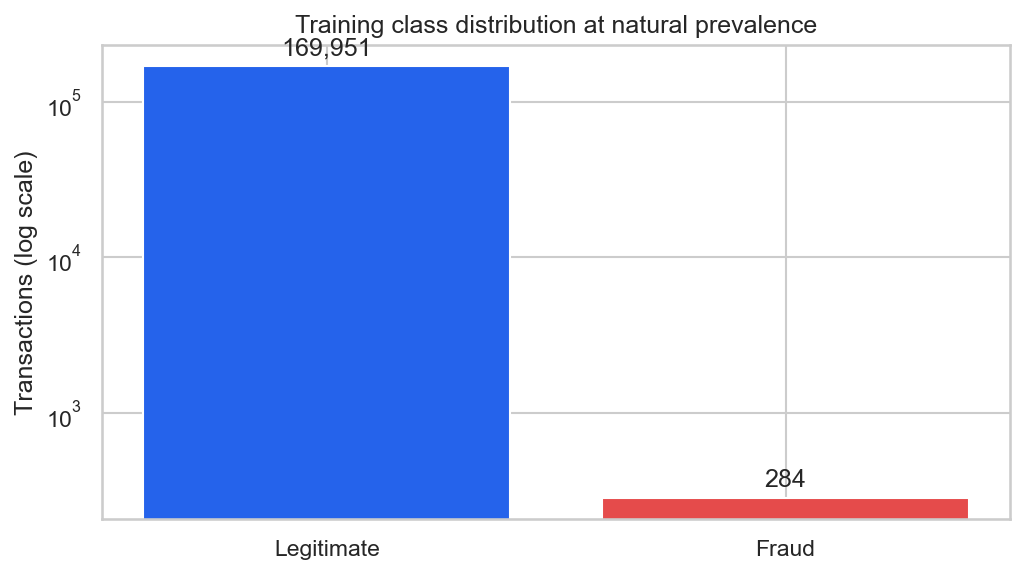

**Insight:** Training has 169,951 legitimate and 284 fraudulent transactions (0.167% fraud). The log axis makes the small fraud class visible. Accuracy is dominated by legitimate records; never balance the evaluation partitions.

In [5]:
figure("class_imbalance.png", eda_insights["class_imbalance"])

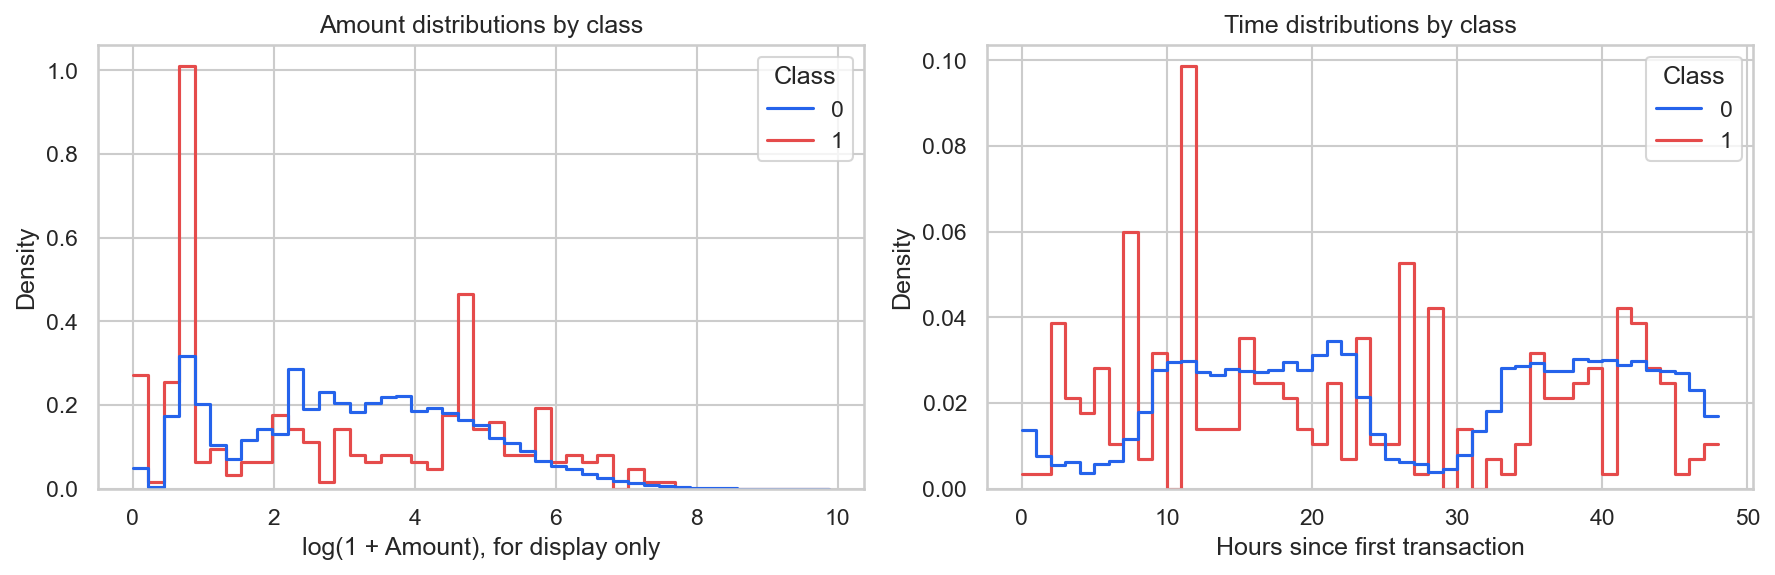

**Insight:** Median Amount is 22.05 for legitimate and 11.86 for fraud. Each class is normalized separately, so compare shapes rather than counts. Log amount is a visualization transform only. Time reflects this short observation window, not a reliable future fraud rule; neither feature alone perfectly separates classes.

In [6]:
figure("amount_time_distributions.png", eda_insights["amount_time_distributions"])

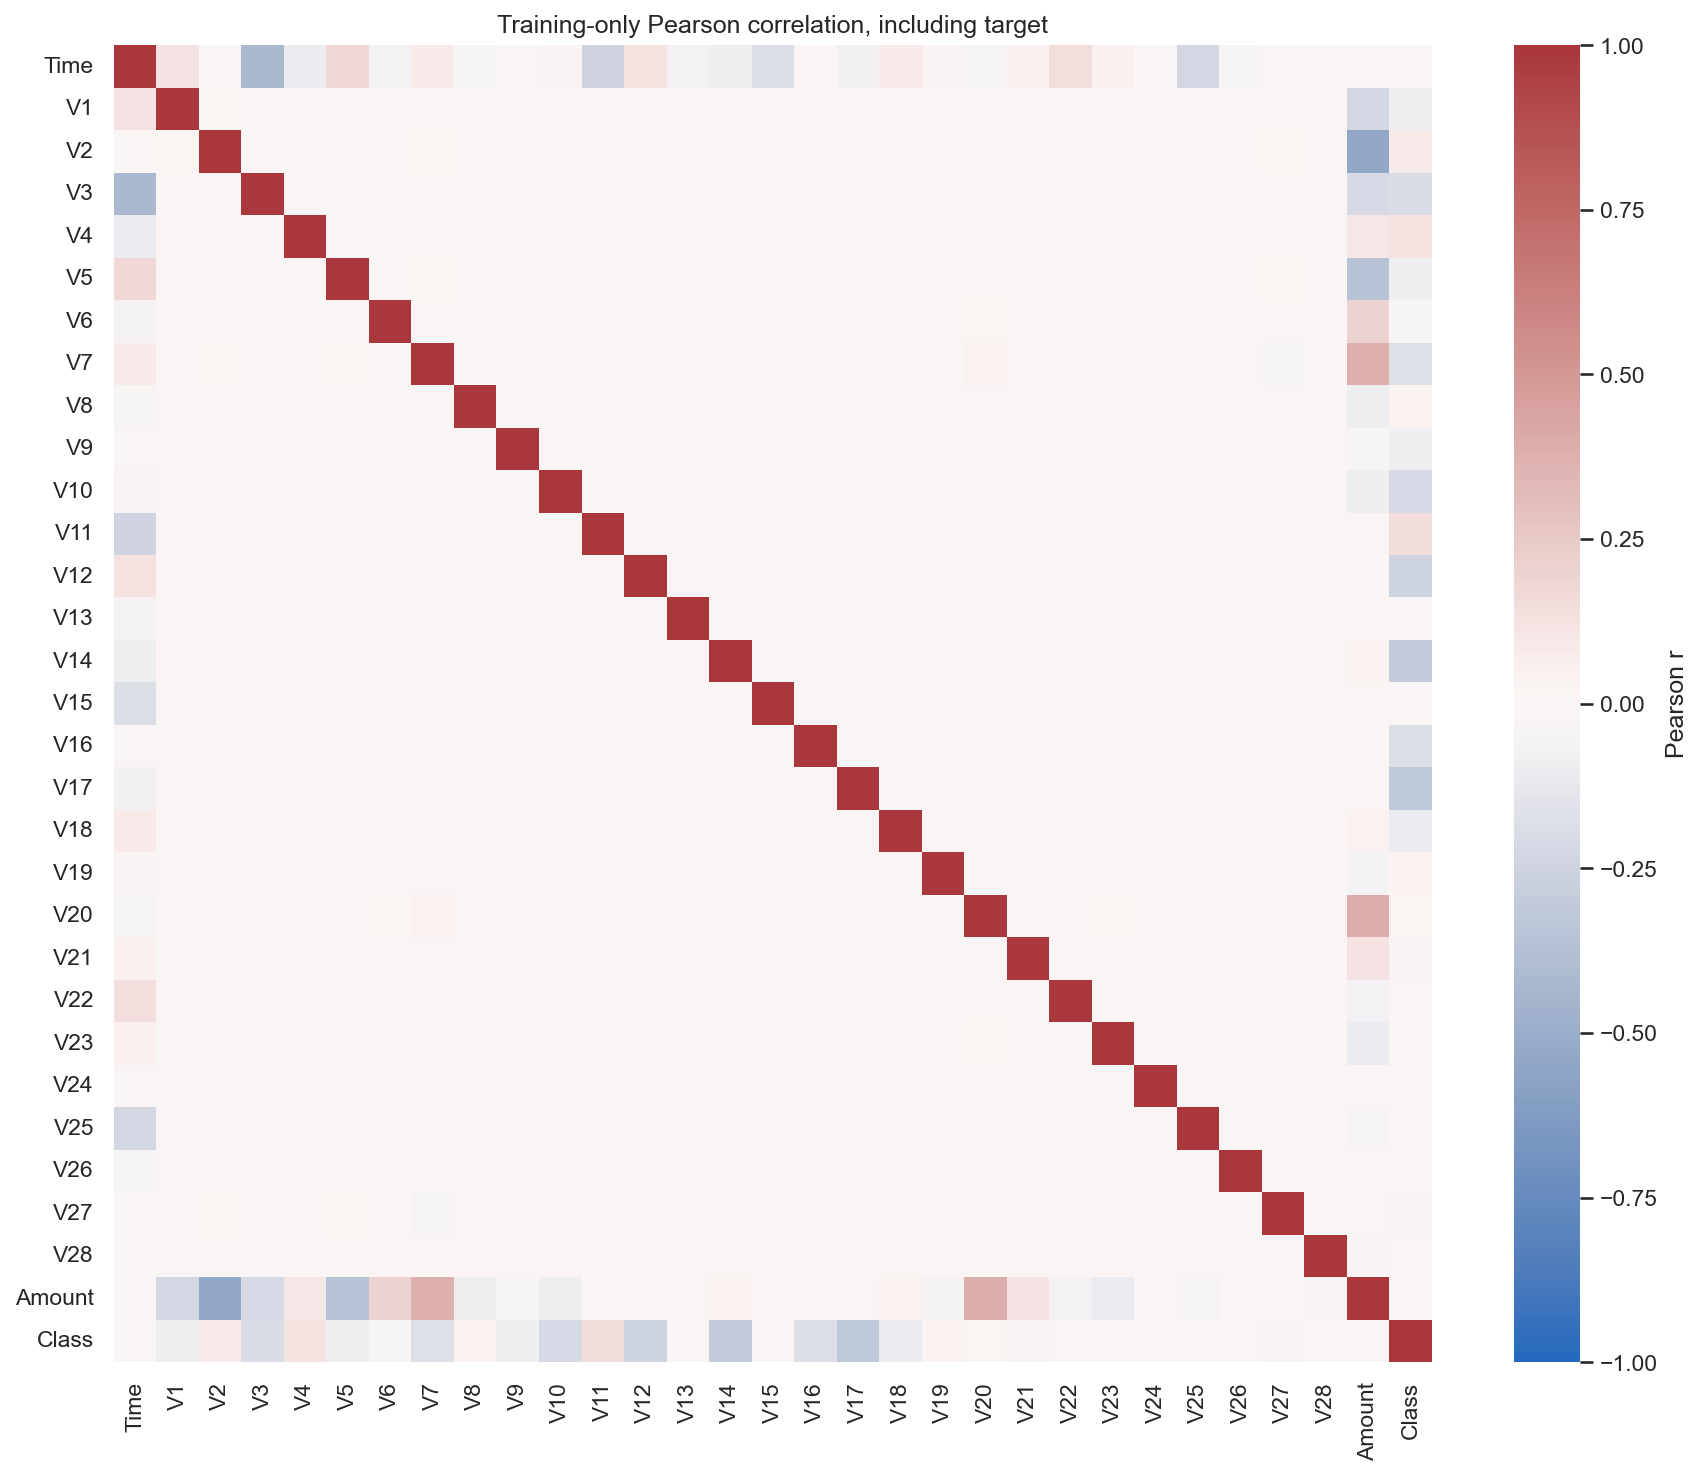

**Insight:** Strongest absolute training target correlations: V17 (0.320), V14 (0.299), V12 (0.251), V10 (0.208). Correlation detects linear associations; low correlation does not exclude nonlinear predictive value. PCA components are anonymized, so correlation cannot reveal business causes.

In [7]:
figure("correlation_heatmap.png", eda_insights["correlation_heatmap"])

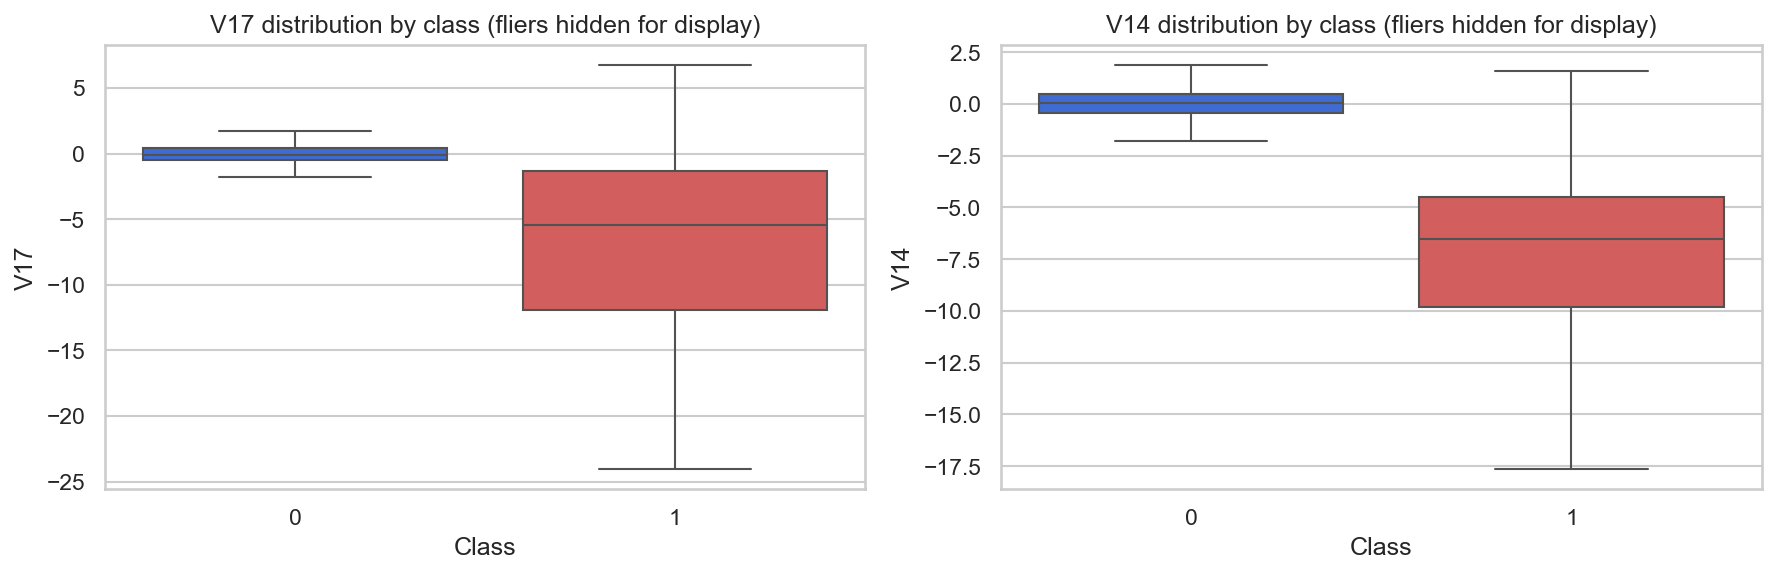

**Insight:** V17, V14 were chosen for display from training target correlations. Different medians or spreads suggest predictive signal, but overlap creates errors. Hiding boxplot fliers improves readability; no rows were removed from training.

In [8]:
figure("pca_distributions.png", eda_insights["pca_distributions"])

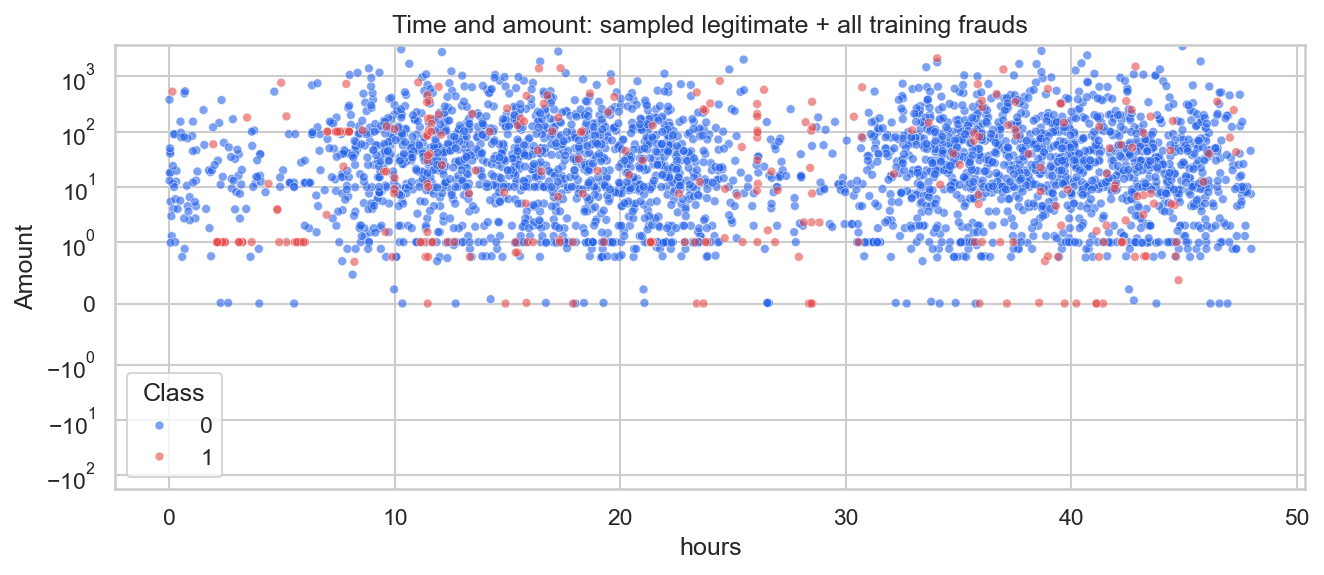

**Insight:** This combines all training frauds with at most 3,000 legitimate records for readable plotting. It does not represent class prevalence. Fraud can occur at small or large amounts; a high-amount-only rule would miss some fraud. The symlog axis retains zero amounts.

In [9]:
figure("time_amount_scatter.png", eda_insights["time_amount_scatter"])

## 5. Model Development
**Feature selection:** SelectKBest chooses the top 20 of 30 by continuous mutual
information with Class. Unlike Pearson correlation, MI can capture nonlinear dependence.
The feature count is fixed in advance for an explicit, manageable experiment. Rankings
use a stratified sample of up to 60,000 training rows and are refitted inside each CV fold.
The transformed full training set is then used to fit the classifier. This reduces
weak predictors and runtime; it is not a claim that 20 is optimal.

Training-only Random Forest importance provides a second descriptive view. It does not
change selection after evaluation. Both individual MI and impurity importance have
limitations: they can miss interactions or favor continuous predictors. A feature-count
ablation is future work.

,feature,mutual_information,selected
0,V17,0.007702,True
1,V14,0.007611,True
2,V10,0.007274,True
3,V12,0.006951,True
4,V11,0.006345,True
5,V16,0.005773,True
6,V4,0.004620,True
7,V9,0.004364,True
8,V3,0.004240,True
9,V7,0.004002,True


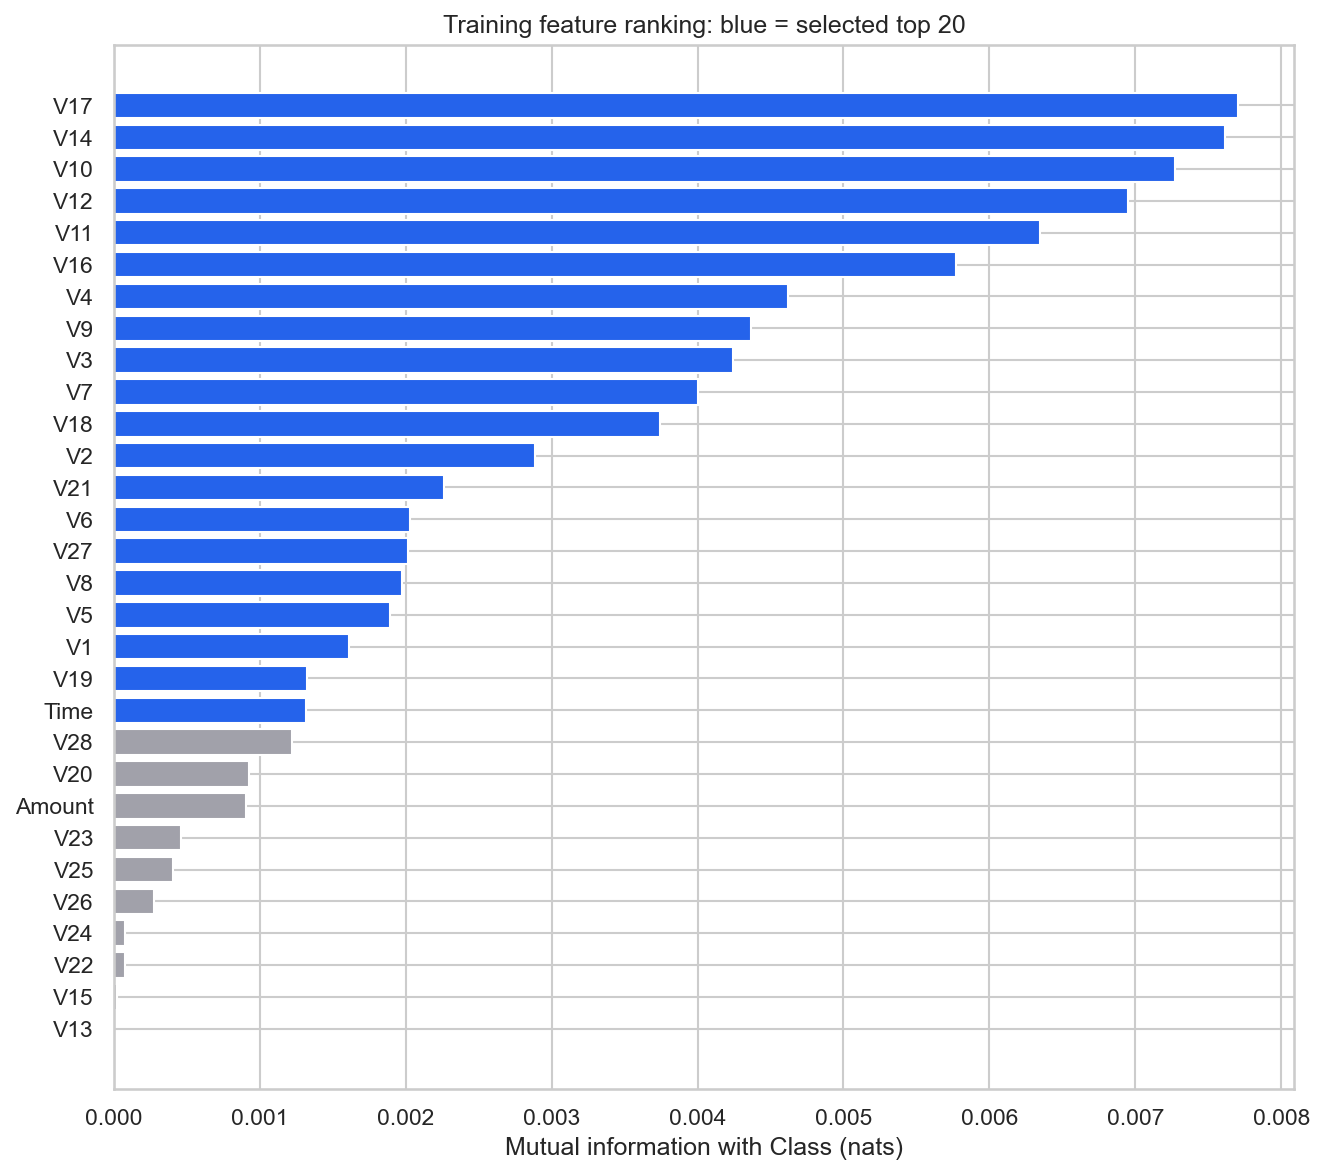

**Insight:** We keep the top 20 of 30 features by mutual information with Class, estimated on 60,000 stratified training rows containing 100 frauds. Kept: Time, V1, V2, V3, V4, V5, V6, V7, V8, V9, V10, V11, V12, V14, V16, V17, V18, V19, V21, V27. The count was fixed before test evaluation to reduce weak predictors and runtime, not claimed to be optimal. Mutual information can capture nonlinear dependence. The forest importance is a secondary descriptive view, not a new test-driven selection rule. Individual rankings can miss interactions; impurity importance can favor continuous variables. Every CV fold relearns selection using its own training data, so its selected columns may differ.

,feature,importance
0,V17,0.162903
1,V12,0.133050
2,V14,0.117934
3,V11,0.110797
4,V16,0.087361
5,V10,0.072707
6,V9,0.055883
7,V4,0.033591
8,Time,0.026994
9,V7,0.026886


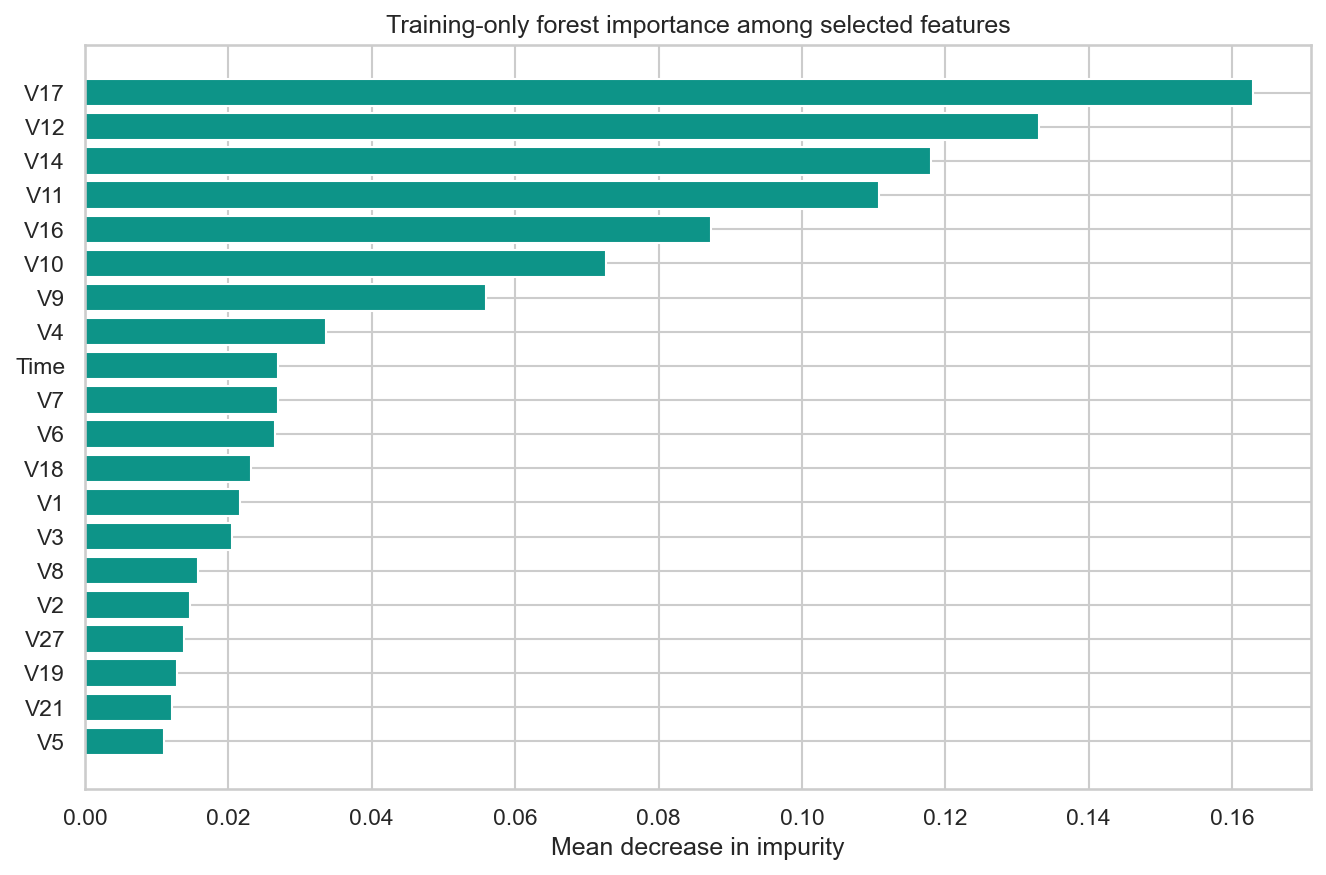

**Insight:** Forest importance is learned only from training examples. High importance suggests useful splits, not a causal business explanation. This secondary view does not replace the predeclared MI selection rule.

In [10]:
display(table("results/feature_selection.csv"))
feature_explanation = (ROOT / "results/feature_selection_explanation.md").read_text(encoding="utf-8")
figure("feature_selection.png", feature_explanation)
importance = table("results/feature_importance.csv")
display(importance)
figure("feature_importance.png", "Forest importance is learned only from training examples. "
       "High importance suggests useful splits, not a causal business explanation. This secondary "
       "view does not replace the predeclared MI selection rule.")

| Algorithm | Why include it? | Main limitation |
|---|---|---|
| Logistic Regression | Fast, regularized linear baseline with probability output | May underfit nonlinear interactions |
| Decision Tree | Nonlinear splits, simple rule structure | High variance; can overfit rare frauds |
| Random Forest | Averages randomized trees to reduce variance | Higher compute and less direct interpretation |

Each algorithm is fitted **without resampling** and **with SMOTE**, yielding six
baseline configurations. SMOTE interpolates between nearby minority training points.
We use a fraud/legitimate ratio of 0.10, which limits synthetic growth and keeps all
real training records. Validation and test data stay naturally imbalanced.

Tune all six configurations using **RandomizedSearchCV**, 3 candidate combinations,
3 stratified folds, and AP scoring. Search at most 60,000 natural-prevalence training
rows for reasonable runtime, then refit each winning setting on all training records.
The complete pipeline includes imputation → scaling → selection → SMOTE → classifier,
so CV never fits these steps on held-out folds. SMOTE is skipped during prediction.

In [11]:
display(table("results/baseline_validation.csv")[["algorithm", "imbalance", "fit_seconds",
                                               "precision", "recall", "f1", "average_precision"]])
display(table("results/cv_fold_summary.csv"))
tuning = table("results/tuning_summary.csv")
display(tuning[["algorithm", "imbalance", "search_rows", "search_frauds", "candidates", "folds",
                "cv_average_precision", "cv_ap_std", "best_params"]])
display(table("results/before_after_tuning.csv"))

,algorithm,imbalance,fit_seconds,precision,recall,f1,average_precision
0,Logistic Regression,None,21.803792,0.898551,0.659574,0.760736,0.797213
1,Logistic Regression,SMOTE,3.815194,0.417910,0.893617,0.569492,0.800913
2,Decision Tree,None,14.959993,0.795699,0.787234,0.791444,0.718509
3,Decision Tree,SMOTE,16.139523,0.236923,0.819149,0.367542,0.599170
4,Random Forest,None,86.708696,0.906977,0.829787,0.866667,0.865882
5,Random Forest,SMOTE,77.034711,0.842105,0.851064,0.846561,0.832645


,fold,train_rows,train_frauds,validation_rows,validation_frauds
0,1,40000,67,20000,33
1,2,40000,67,20000,33
2,3,40000,66,20000,34


,algorithm,imbalance,search_rows,search_frauds,candidates,folds,cv_average_precision,cv_ap_std,best_params
0,Logistic Regression,None,60000,100,3,3,0.694201,0.046821,"{""classifier__C"": 0.01, ""classifier__tol"": 0.001}"
1,Logistic Regression,SMOTE,60000,100,3,3,0.671803,0.050485,"{""classifier__C"": 0.01, ""classifier__tol"": 0.001}"
2,Decision Tree,None,60000,100,3,3,0.631044,0.016492,"{""classifier__criterion"": ""gini"", ""classifier_..."
3,Decision Tree,SMOTE,60000,100,3,3,0.466391,0.028728,"{""classifier__criterion"": ""gini"", ""classifier_..."
4,Random Forest,None,60000,100,3,3,0.764969,0.030014,"{""classifier__max_depth"": 8, ""classifier__max_..."
5,Random Forest,SMOTE,60000,100,3,3,0.763720,0.029713,"{""classifier__max_depth"": null, ""classifier__m..."


,algorithm,imbalance,accuracy_before,accuracy_after,precision_before,precision_after,recall_before,recall_after,f1_before,f1_after,roc_auc_before,roc_auc_after,average_precision_before,average_precision_after,pr_auc_before,pr_auc_after
0,Logistic Regression,None,0.999313,0.999348,0.898551,0.913043,0.659574,0.670213,0.760736,0.773006,0.973703,0.980160,0.797213,0.794897,0.796363,0.793927
1,Logistic Regression,SMOTE,0.997762,0.997956,0.417910,0.442105,0.893617,0.893617,0.569492,0.591549,0.977871,0.978156,0.800913,0.802104,0.799995,0.801186
2,Decision Tree,None,0.999313,0.999454,0.795699,0.870588,0.787234,0.787234,0.791444,0.826816,0.865107,0.941250,0.718509,0.834179,0.756828,0.863274
3,Decision Tree,SMOTE,0.995330,0.996951,0.236923,0.333333,0.819149,0.840426,0.367542,0.477341,0.894853,0.940303,0.599170,0.550881,0.477327,0.692910
4,Random Forest,None,0.999577,0.999559,0.906977,0.915663,0.829787,0.808511,0.866667,0.858757,0.973658,0.967054,0.865882,0.857907,0.865625,0.857578
5,Random Forest,SMOTE,0.999489,0.999559,0.842105,0.870968,0.851064,0.861702,0.846561,0.866310,0.977199,0.954602,0.832645,0.839875,0.831612,0.845670


**Reading tuning results:** better CV AP need not improve one held-out validation set
or the F1 at threshold 0.5. Few frauds make rankings noisy; inspect CV standard deviations.
The bounded sample/search is a runtime choice and a limitation. Baselines remain eligible
if the tuned setting performs worse on the independent validation partition.

## 6. Model Evaluation
Accuracy, precision, recall, and F1 use a classification threshold. ROC-AUC and PR
metrics use probability scores across thresholds. TN/FP/FN/TP connect scores to
genuine customers flagged and frauds missed.

**AP versus PR-AUC:** AP weights precision by increments in recall; trapezoidal PR-AUC
interpolates PR points. We report both and tune/select on AP. The constant legitimate
reference has no-skill AP equal to prevalence; its interpolated PR area can look
misleadingly high because of endpoints. See [the AP definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).

In [12]:
comparisons = table("results/model_comparison.csv")
metadata = json.loads((ROOT / "models/metadata.json").read_text())
metric_columns = ["experiment", "partition", "threshold", "accuracy", "precision", "recall",
                  "f1", "roc_auc", "average_precision", "pr_auc", "tn", "fp", "fn", "tp"]
display(comparisons[comparisons.partition == "test"][metric_columns])

,experiment,partition,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,pr_auc,tn,fp,fn,tp
12,Logistic Regression | None | baseline,test,0.500000,0.999101,0.854839,0.557895,0.675159,0.958164,0.691147,0.689593,56642,9,42,53
13,Logistic Regression | SMOTE | baseline,test,0.500000,0.997462,0.379310,0.810526,0.516779,0.961812,0.686924,0.684927,56525,126,18,77
14,Decision Tree | None | baseline,test,0.500000,0.999260,0.804598,0.736842,0.769231,0.909105,0.695386,0.730209,56634,17,25,70
15,Decision Tree | SMOTE | baseline,test,0.500000,0.995683,0.244898,0.757895,0.370180,0.862687,0.630324,0.523779,56429,222,23,72
16,Random Forest | None | baseline,test,0.500000,0.999489,0.958333,0.726316,0.826347,0.953836,0.779193,0.779115,56648,3,26,69
17,Random Forest | SMOTE | baseline,test,0.500000,0.999418,0.869048,0.768421,0.815642,0.976194,0.799301,0.798883,56640,11,22,73
18,Logistic Regression | None | tuned,test,0.500000,0.999101,0.866667,0.547368,0.670968,0.960956,0.686495,0.684617,56643,8,43,52
19,Logistic Regression | SMOTE | tuned,test,0.500000,0.997815,0.419890,0.800000,0.550725,0.962280,0.688259,0.686283,56546,105,19,76
20,Decision Tree | None | tuned,test,0.500000,0.999277,0.855263,0.684211,0.760234,0.889027,0.690673,0.745482,56640,11,30,65
21,Decision Tree | SMOTE | tuned,test,0.500000,0.997057,0.337838,0.789474,0.473186,0.898686,0.495618,0.640636,56504,147,20,75


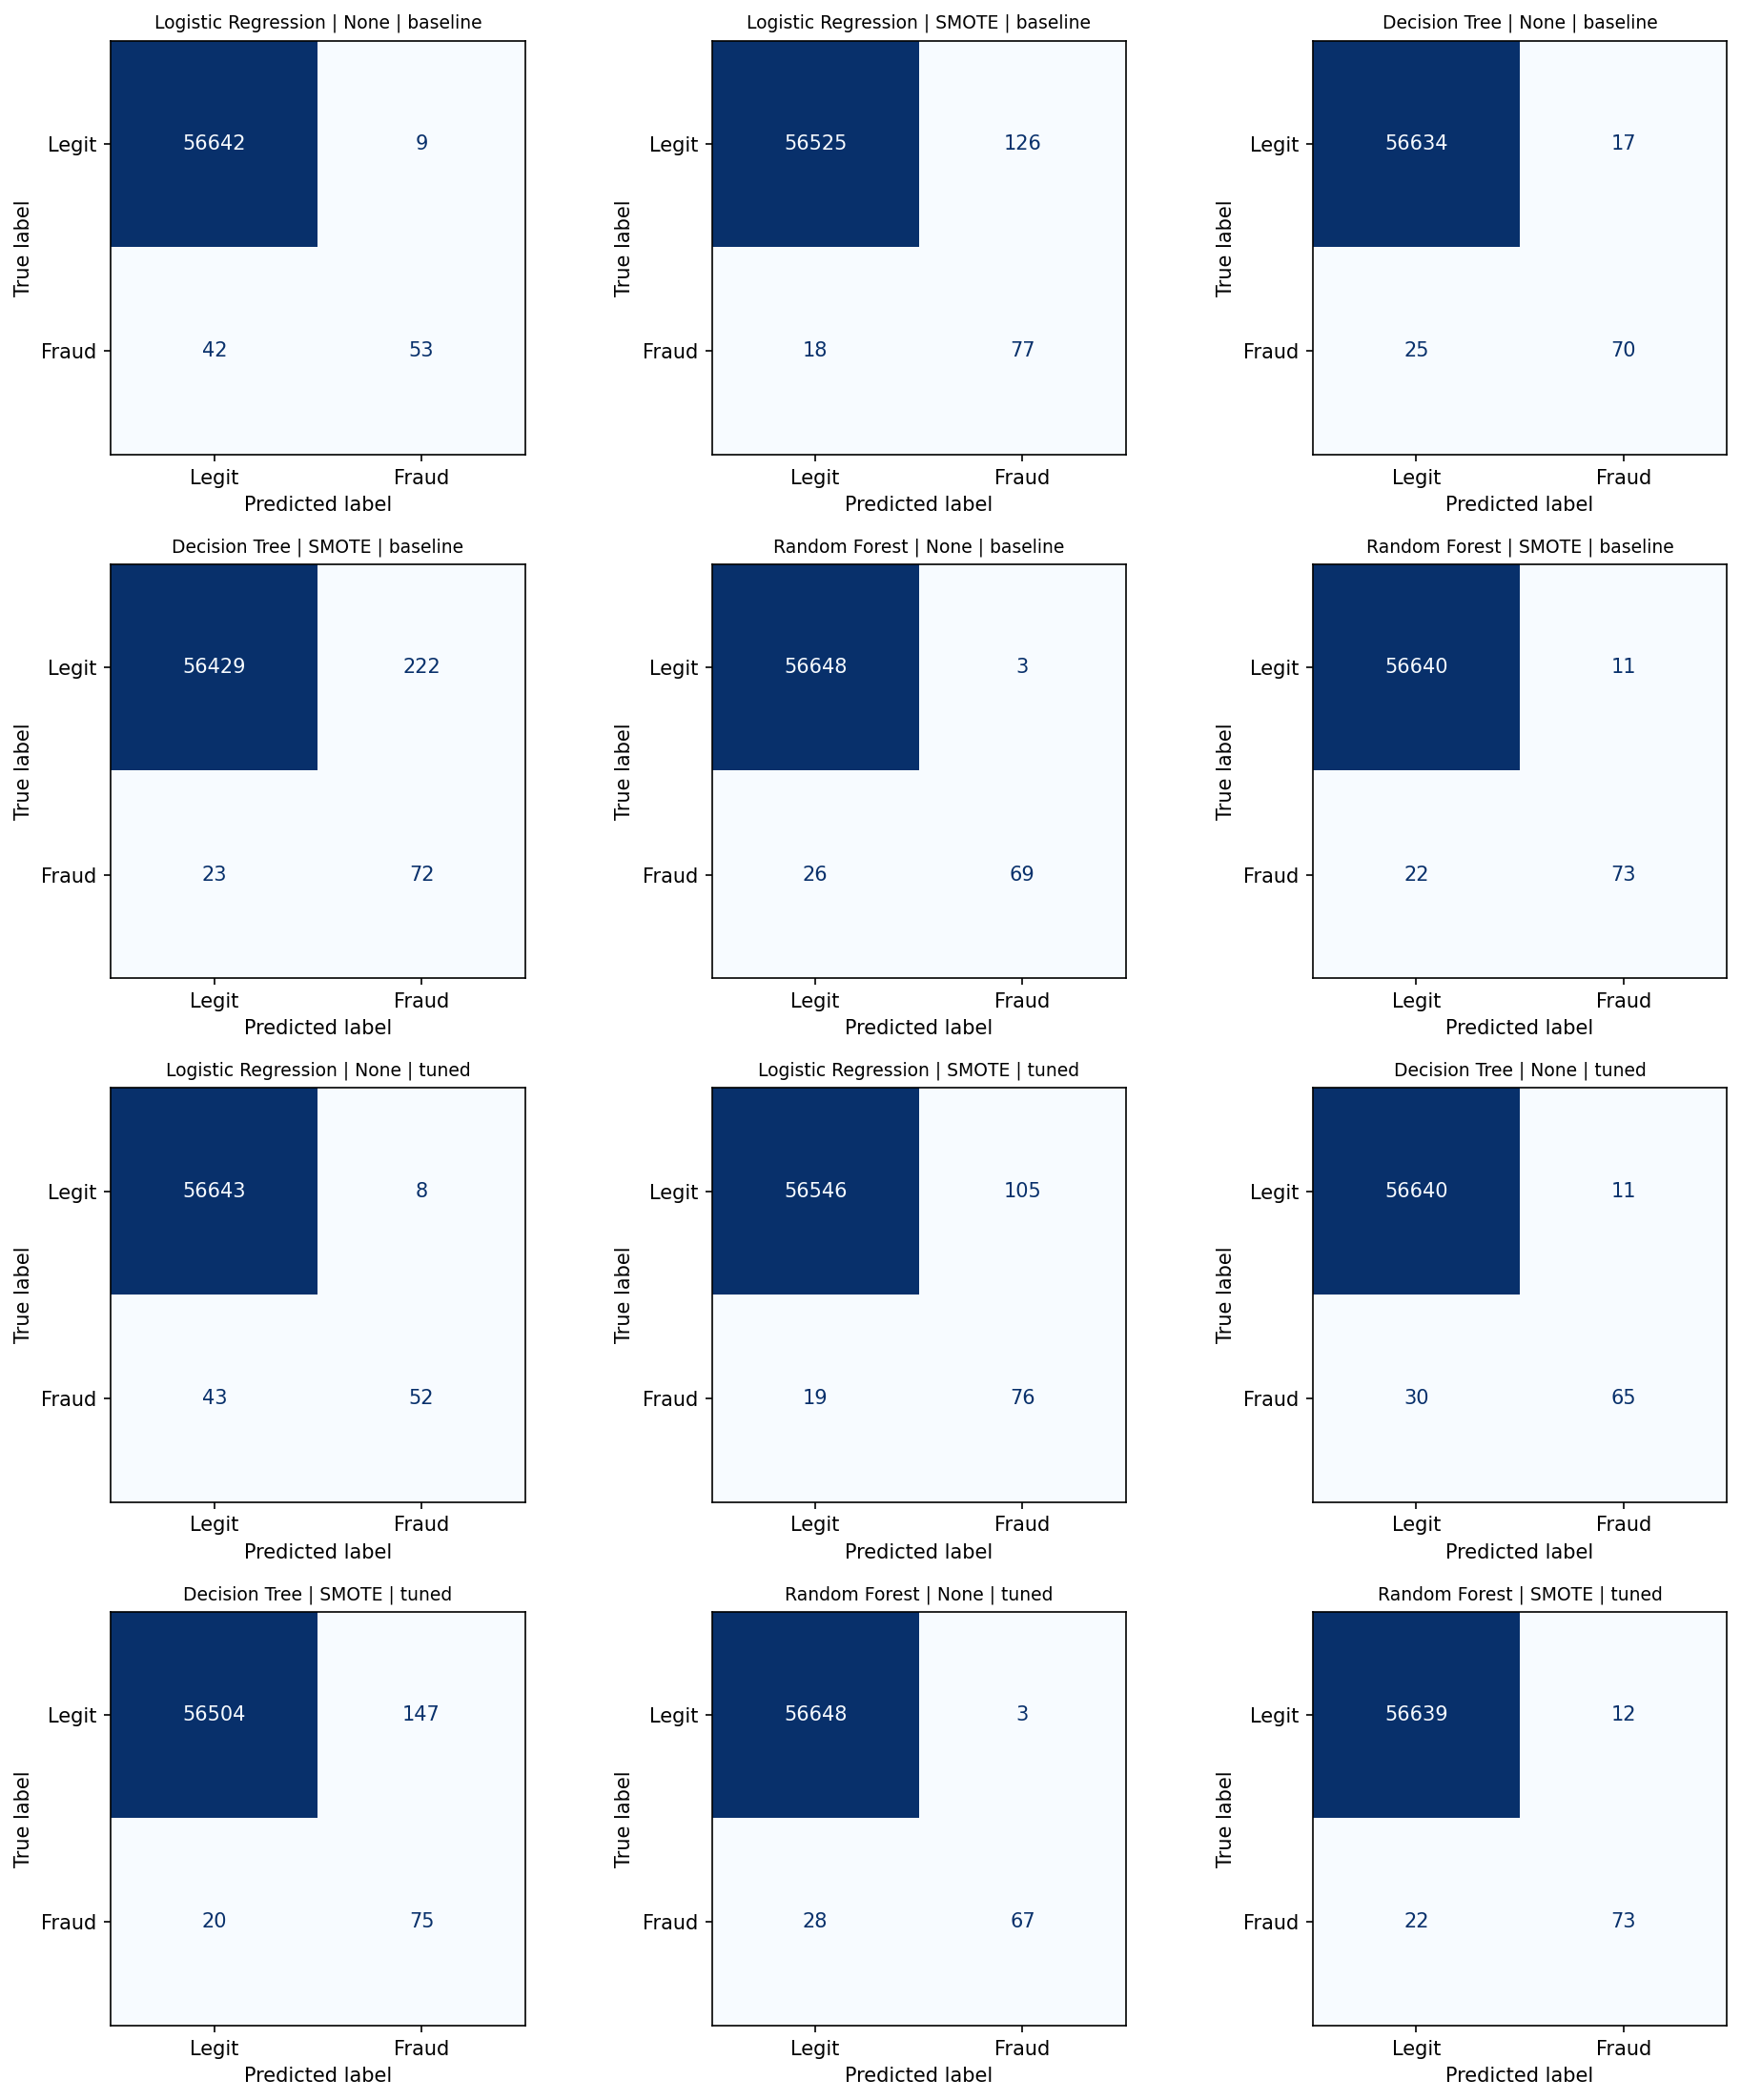

**Insight:** All twelve frozen configurations use threshold 0.5 for this comparison. Examine false negatives for missed fraud and false positives for review workload; total accuracy alone hides these differences.

In [13]:
figure("test_confusion_matrices.png", "All twelve frozen configurations use threshold 0.5 "
       "for this comparison. Examine false negatives for missed fraud and false positives "
       "for review workload; total accuracy alone hides these differences.")

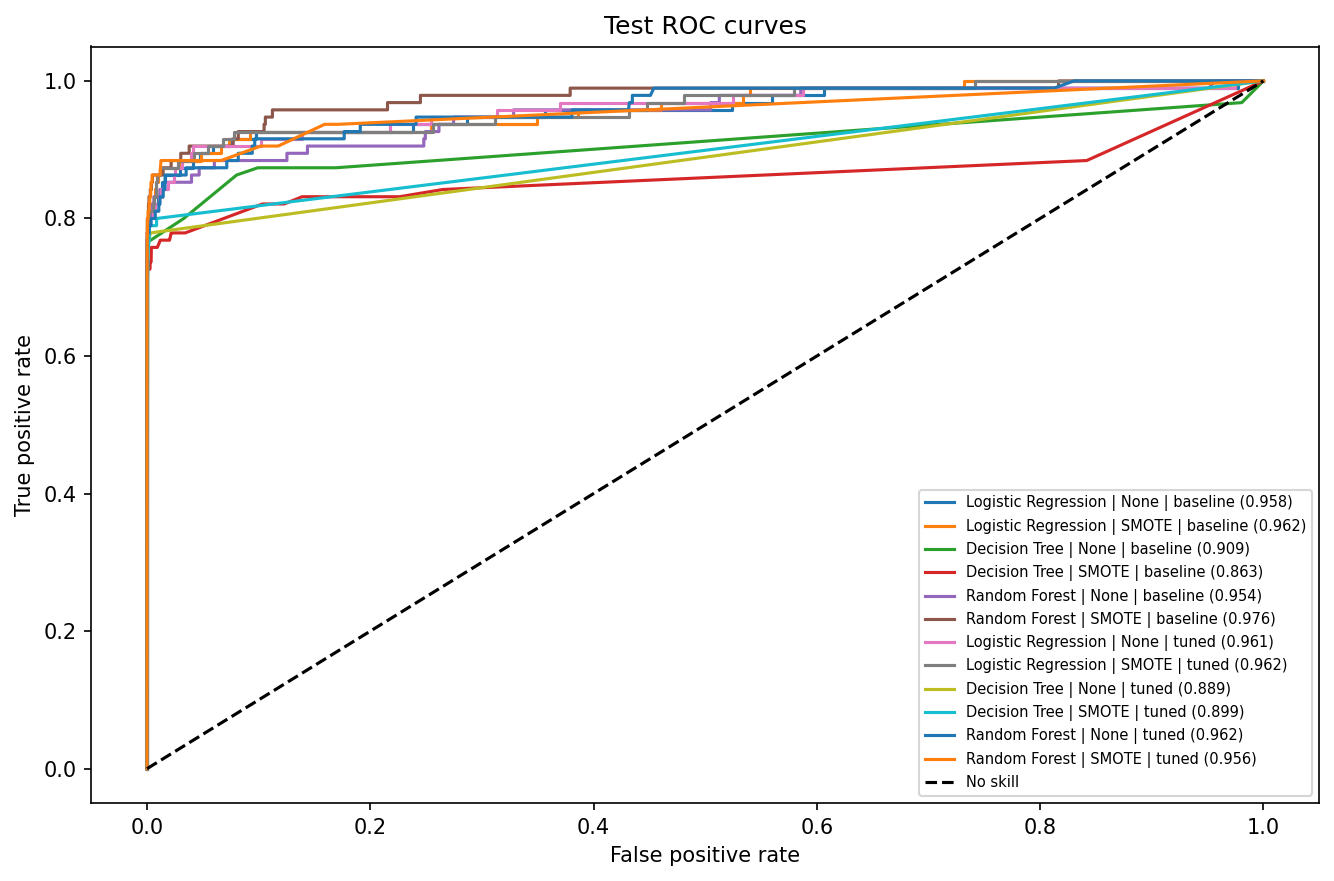

**Insight:** ROC-AUC compares ranking across false-positive and true-positive rates. A small false-positive rate can still mean many false alerts when legitimate records dominate. These test curves describe frozen choices and were not used to select the deployed model.

In [14]:
figure("test_roc_curves.png", "ROC-AUC compares ranking across false-positive and true-positive rates. "
       "A small false-positive rate can still mean many false alerts when legitimate records dominate. "
       "These test curves describe frozen choices and were not used to select the deployed model.")

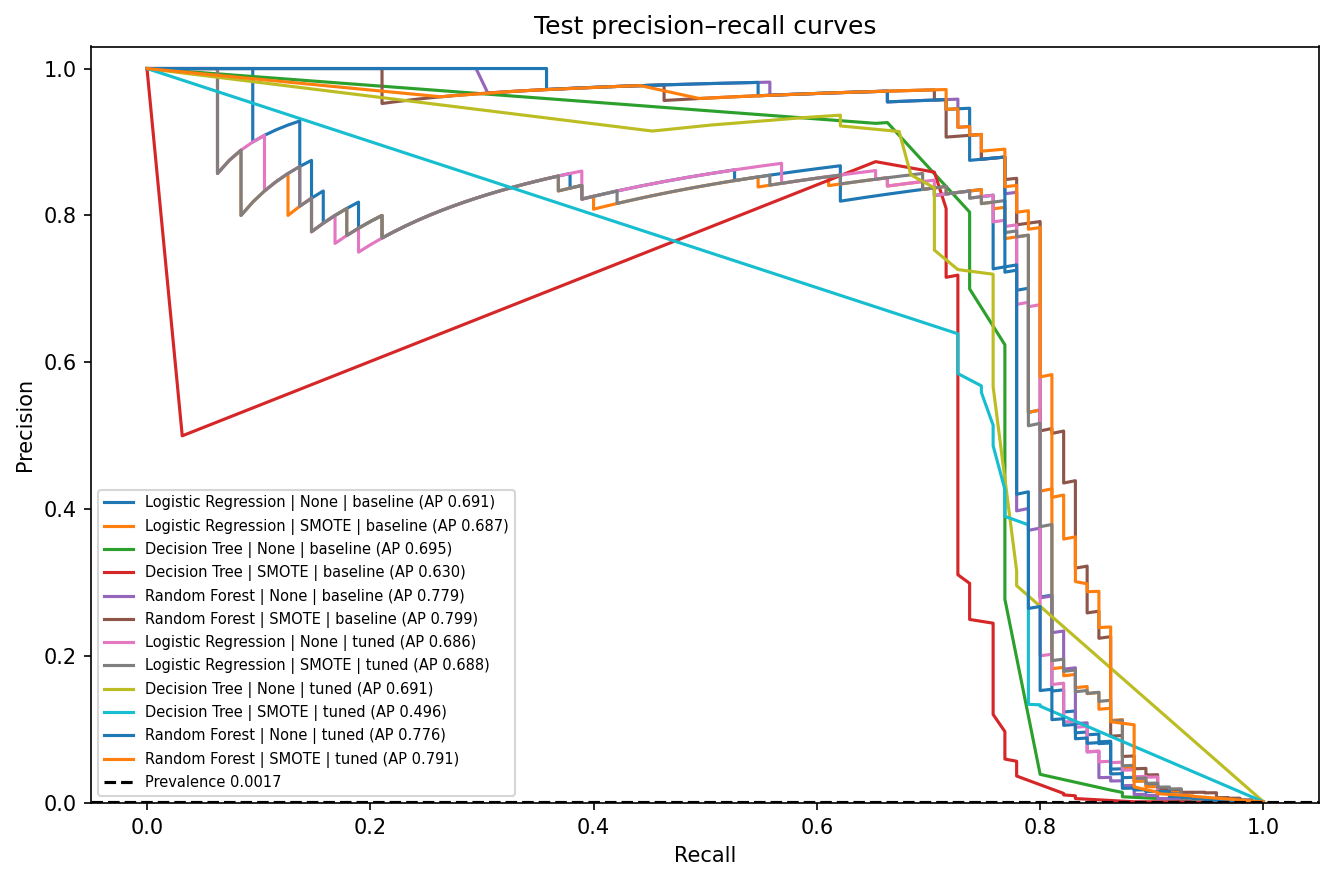

**Insight:** Precision–recall curves show alert reliability versus fraud coverage. The horizontal reference equals test fraud prevalence. AP is the primary ranking metric because it reflects precision when fraud is rare.

In [15]:
figure("test_pr_curves.png", "Precision–recall curves show alert reliability versus fraud coverage. "
       "The horizontal reference equals test fraud prevalence. AP is the primary ranking metric "
       "because it reflects precision when fraud is rare.")

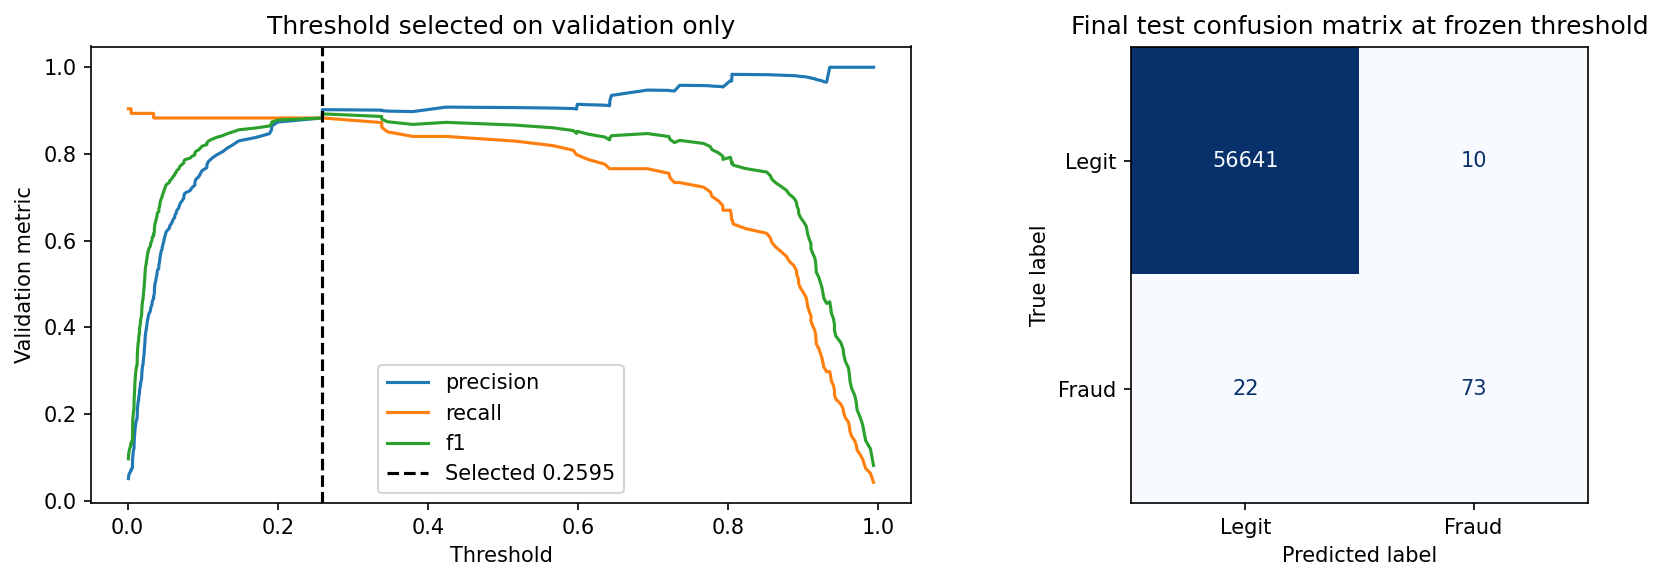

**Insight:** The left plot uses validation only to select threshold 0.259462; the right applies it to test records. It catches 73 frauds, misses 22, and raises 10 false alerts. F1 gains on validation need not transfer to test; the threshold is retained because selection was already frozen.

In [16]:
m = metadata["final_test_metrics"]
figure("final_threshold_and_confusion.png", f"The left plot uses validation only to select threshold "
       f"{metadata['threshold']:.6f}; the right applies it to test records. It catches {m['tp']} frauds, "
       f"misses {m['fn']}, and raises {m['fp']} false alerts. F1 gains on validation need not transfer "
       "to test; the threshold is retained because selection was already frozen.")

## 7. Model Comparison
The table includes **all models × all required metrics**, with/without SMOTE and
before/after tuning, plus the dummy and selected operating threshold. Validation guides
selection; test estimates frozen choices. AP is threshold-independent for a fixed model,
so changing its decision threshold changes precision/recall/F1 but leaves AP and ROC-AUC fixed.

In [17]:
display(comparisons[["algorithm", "imbalance", "stage", "partition", "threshold", "accuracy",
                     "precision", "recall", "f1", "roc_auc", "average_precision", "pr_auc",
                     "tn", "fp", "fn", "tp"]])
display(Markdown((ROOT / "results/findings.md").read_text(encoding="utf-8")))

,algorithm,imbalance,stage,partition,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,pr_auc,tn,fp,fn,tp
0,Logistic Regression,None,baseline,validation,0.500000,0.999313,0.898551,0.659574,0.760736,0.973703,0.797213,0.796363,56644,7,32,62
1,Logistic Regression,SMOTE,baseline,validation,0.500000,0.997762,0.417910,0.893617,0.569492,0.977871,0.800913,0.799995,56534,117,10,84
2,Decision Tree,None,baseline,validation,0.500000,0.999313,0.795699,0.787234,0.791444,0.865107,0.718509,0.756828,56632,19,20,74
3,Decision Tree,SMOTE,baseline,validation,0.500000,0.995330,0.236923,0.819149,0.367542,0.894853,0.599170,0.477327,56403,248,17,77
4,Random Forest,None,baseline,validation,0.500000,0.999577,0.906977,0.829787,0.866667,0.973658,0.865882,0.865625,56643,8,16,78
5,Random Forest,SMOTE,baseline,validation,0.500000,0.999489,0.842105,0.851064,0.846561,0.977199,0.832645,0.831612,56636,15,14,80
6,Logistic Regression,None,tuned,validation,0.500000,0.999348,0.913043,0.670213,0.773006,0.980160,0.794897,0.793927,56645,6,31,63
7,Logistic Regression,SMOTE,tuned,validation,0.500000,0.997956,0.442105,0.893617,0.591549,0.978156,0.802104,0.801186,56545,106,10,84
8,Decision Tree,None,tuned,validation,0.500000,0.999454,0.870588,0.787234,0.826816,0.941250,0.834179,0.863274,56640,11,20,74
9,Decision Tree,SMOTE,tuned,validation,0.500000,0.996951,0.333333,0.840426,0.477341,0.940303,0.550881,0.692910,56493,158,15,79


# Measured findings

## Model and threshold selection

Selected **Random Forest | None | baseline** using validation AP 0.8659. The frozen threshold is **0.259462**, selected by validation F1. No test labels were used to select either. All configurations were fixed before test evaluation.

## Effect of SMOTE (validation, threshold 0.5)

- Logistic Regression, baseline: AP 0.7972 → 0.8009; precision 0.899 → 0.418; recall 0.660 → 0.894; false alerts 7 → 117. Synthetic interpolation changes the learned boundary; it can increase overlap as well as improve minority coverage.
- Decision Tree, baseline: AP 0.7185 → 0.5992; precision 0.796 → 0.237; recall 0.787 → 0.819; false alerts 19 → 248. Synthetic interpolation changes the learned boundary; it can increase overlap as well as improve minority coverage.
- Random Forest, baseline: AP 0.8659 → 0.8326; precision 0.907 → 0.842; recall 0.830 → 0.851; false alerts 8 → 15. Synthetic interpolation changes the learned boundary; it can increase overlap as well as improve minority coverage.
- Logistic Regression, tuned: AP 0.7949 → 0.8021; precision 0.913 → 0.442; recall 0.670 → 0.894; false alerts 6 → 106. Synthetic interpolation changes the learned boundary; it can increase overlap as well as improve minority coverage.
- Decision Tree, tuned: AP 0.8342 → 0.5509; precision 0.871 → 0.333; recall 0.787 → 0.840; false alerts 11 → 158. Synthetic interpolation changes the learned boundary; it can increase overlap as well as improve minority coverage.
- Random Forest, tuned: AP 0.8579 → 0.8399; precision 0.916 → 0.871; recall 0.809 → 0.862; false alerts 7 → 12. Synthetic interpolation changes the learned boundary; it can increase overlap as well as improve minority coverage.

## Effect of tuning (validation)

- Logistic Regression, None: AP 0.7972 → 0.7949; F1 0.7607 → 0.7730. CV optimizes AP on a smaller training sample, so tuning is not guaranteed to improve a particular validation split or its 0.5-threshold F1.
- Logistic Regression, SMOTE: AP 0.8009 → 0.8021; F1 0.5695 → 0.5915. CV optimizes AP on a smaller training sample, so tuning is not guaranteed to improve a particular validation split or its 0.5-threshold F1.
- Decision Tree, None: AP 0.7185 → 0.8342; F1 0.7914 → 0.8268. CV optimizes AP on a smaller training sample, so tuning is not guaranteed to improve a particular validation split or its 0.5-threshold F1.
- Decision Tree, SMOTE: AP 0.5992 → 0.5509; F1 0.3675 → 0.4773. CV optimizes AP on a smaller training sample, so tuning is not guaranteed to improve a particular validation split or its 0.5-threshold F1.
- Random Forest, None: AP 0.8659 → 0.8579; F1 0.8667 → 0.8588. CV optimizes AP on a smaller training sample, so tuning is not guaranteed to improve a particular validation split or its 0.5-threshold F1.
- Random Forest, SMOTE: AP 0.8326 → 0.8399; F1 0.8466 → 0.8663. CV optimizes AP on a smaller training sample, so tuning is not guaranteed to improve a particular validation split or its 0.5-threshold F1.

## Bias, variance, and overfitting

Logistic Regression uses a regularized linear boundary and may underfit nonlinear interactions. A tree can represent nonlinear splits but has high variance with few fraud examples. A forest averages many randomized trees to reduce variance. The following gaps are clues to overfitting rather than proofs; training and validation fraud samples differ.

- Logistic Regression | None | baseline: training AP 0.7395, validation AP 0.7972, gap -0.0577.
- Logistic Regression | SMOTE | baseline: training AP 0.7419, validation AP 0.8009, gap -0.0590.
- Decision Tree | None | baseline: training AP 0.9068, validation AP 0.7185, gap +0.1883.
- Decision Tree | SMOTE | baseline: training AP 0.8750, validation AP 0.5992, gap +0.2758.
- Random Forest | None | baseline: training AP 0.9758, validation AP 0.8659, gap +0.1099.
- Random Forest | SMOTE | baseline: training AP 0.9958, validation AP 0.8326, gap +0.1631.
- Logistic Regression | None | tuned: training AP 0.7426, validation AP 0.7949, gap -0.0523.
- Logistic Regression | SMOTE | tuned: training AP 0.7439, validation AP 0.8021, gap -0.0582.
- Decision Tree | None | tuned: training AP 0.9142, validation AP 0.8342, gap +0.0800.
- Decision Tree | SMOTE | tuned: training AP 0.9731, validation AP 0.5509, gap +0.4223.
- Random Forest | None | tuned: training AP 0.9187, validation AP 0.8579, gap +0.0608.
- Random Forest | SMOTE | tuned: training AP 0.9994, validation AP 0.8399, gap +0.1595.

## Final held-out result

On 56,746 untouched test records, the selected operating threshold finds 73 of 95 frauds, misses 22, and raises 10 false alerts. Precision 0.8795; recall 0.7684; F1 0.8202; ROC-AUC 0.9538; AP 0.7792; trapezoidal PR-AUC 0.7791.

At threshold 0.5, this same model has 3 false alerts and 26 missed frauds. Test F1 changes from 0.8263 to 0.8202 at the validation-selected threshold. A validation gain does not guarantee a test gain, so we keep the already frozen threshold. A lower threshold generally exchanges review workload for fraud coverage. The optimal business choice requires bank-specific losses and capacity; no dollar costs are invented.

AP and trapezoidal PR-AUC use different interpolation rules. Constant scores have a no-skill AP equal to prevalence, while their trapezoidal area can be misleadingly high because of the endpoint interpolation. This is why AP is the primary ranking metric.

## Limitations and future work

Anonymized PCA features and an unavailable transform prevent direct use of ordinary card details. Two days from 2013 are a limited benchmark; modern deployment requires concept-drift monitoring. Random stratification can be optimistic compared with a temporal split. There are few held-out frauds, deduplication changes benchmark counts, MI can miss interactions, and the small search is noisy. SMOTE probability scores are not independently calibrated. Future work includes temporal evaluation, feature-count ablation, class-weight comparisons, larger/nested CV, calibration, and thresholds based on costs and review capacity.


**Business tradeoff:** false negatives risk lost funds and trust; false positives cost
review effort and inconvenience customers. Maximum validation F1 is a classroom operating
choice. Real systems should use bank-specific losses and review capacity, without
inventing costs for this anonymized dataset. Scores are not independently calibrated;
SMOTE changes training priors and may especially distort probability interpretation.

## 8. Deployment / Demonstration
The full pipeline is saved with joblib, along with its fitted scaler, preprocessor,
selected feature list, threshold, dataset SHA256, and version metadata. The Streamlit
app loads these artifacts and accepts single transactions or CSV batches.

Run from the project directory:

```powershell
python -m streamlit run app.py
```

Open `http://localhost:8501`, load a real example or enter all 30 raw numeric values,
and submit a prediction. For batch scoring, upload a CSV with Time,V1,…,V28,Amount;
Class is optional and ignored for prediction. Download the scored result. Missing or
invalid values receive helpful errors. Ordinary card details cannot be mapped to
V1–V28 without the unavailable original PCA transform.

In [18]:
bundle = load_artifacts(ROOT / "models")  # Also loads and checks the saved scaler/features.
examples = table("results/example_transactions.csv")
single = predict_transactions(examples.iloc[[0]], bundle)
batch = predict_transactions(examples, bundle)
display(single[["Class", "fraud_probability", "prediction", "decision_threshold"]])
display(batch[["Time", "Amount", "Class", "fraud_probability", "prediction", "decision_threshold"]])
np.testing.assert_allclose(single.fraud_probability.iloc[0], batch.fraud_probability.iloc[0])
print("Saved inference pipeline:", metadata["experiment"])
print("Selected features:", bundle.selected_features)
print("Scaler:", bundle.scaler)
print("SMOTE is skipped for inference; raw inputs are scaled exactly once.")

,Class,fraud_probability,prediction,decision_threshold
0,0,0.00002,Legitimate,0.259462


,Time,Amount,Class,fraud_probability,prediction,decision_threshold
0,61290.0,11.50,0,0.000020,Legitimate,0.259462
1,155394.0,1.94,0,0.000022,Legitimate,0.259462
2,30881.0,91.28,0,0.000467,Legitimate,0.259462
3,74159.0,76.94,1,0.743429,Potential fraud,0.259462
4,65385.0,1354.25,1,0.695000,Potential fraud,0.259462
5,150494.0,1.00,1,0.019181,Legitimate,0.259462


Saved inference pipeline: Random Forest | None | baseline
Selected features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V21', 'V27']
Scaler: ColumnTransformer(transformers=[('time_amount', RobustScaler(),
                                 ['Time', 'Amount']),
                                ('pca', StandardScaler(),
                                 ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7',
                                  'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14',
                                  'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
                                  'V21', 'V22', 'V23', 'V24', 'V25', 'V26',
                                  'V27', 'V28'])],
                  verbose_feature_names_out=False)
SMOTE is skipped for inference; raw inputs are scaled exactly once.


**Conclusion:** this complete workflow demonstrates severe imbalance, leakage prevention,
feature selection, meaningful model comparisons, tuning, threshold selection, and a
working prediction path. The measured findings above give the actual final result.

**Limitations:** anonymized PCA, unavailable transform, a two-day dataset from 2013,
limited held-out frauds, random rather than temporal evaluation, deduplication differences
from raw-data benchmarks, possible SMOTE artifacts, MI interaction loss, a small tuning
budget, and uncalibrated scores.

**Future work:** temporal/group validation, feature-count ablation, class weights and
balanced forests, larger nested CV, independent calibration, cost-based thresholds,
drift monitoring, and human review. See the README's viva Q&A for presentation preparation.